# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos en users:", users.isna().sum())
print("Proporción de valores nulos en users", users.isna().mean())

Cantidad de valores nulos en users: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos en users user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en usage:", usage.isna().sum())
print("Proporción de valores nulos en usage", usage.isna().mean())

Cantidad de valores nulos en usage: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos en usage id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
**En el caso del dataframe users:**
1. El caso de churn_date (88.35% de nulos)
No es un problema, es una métrica de negocio.

Interpretación: Que el 88% de los valores sean nulos significa que la gran mayoría de tus usuarios son clientes activos. Solo el 11.65% ha cancelado el servicio (churn).

Acción: No se debe eliminar esta columna ni imputar con promedios. Los nulos aquí son informativos. Para análisis posteriores, se debe crear una columna booleana llamada is_active donde 1 sea nulo en churn_date y 0 sea que tiene fecha.

2. El caso de city (11.72% de nulos)
Este sí es un problema de integridad de datos.

Interpretación: Tenemos 469 usuarios de los que no sabemos dónde viven. Si el análisis pretende comparar el comportamiento por región, este vacío sesgará los resultados.

Acción Sugerida: * Investigación: ¿Hay algún patrón? (¿Son todos del mismo plan o se registraron en la misma fecha?).

Tratamiento: Si no se puede recuperar la información, podríamos imputarlos como 'Unknown' para no perder las otras métricas de esos usuarios (como su edad o consumo).

**En el caso del dataframe usage:**

1. La "Relación Cruzada" (duration vs length)Es muy probable que estas dos columnas dependan del valor de la columna type.Hipótesis: Si el dataset mezcla llamadas y mensajes de texto, es lógico que las llamadas tengan duration (duración) pero no length (longitud/caracteres), y viceversa para los SMS.El dato crítico: La suma de las proporciones de nulos ($0.55 + 0.44 = 0.99$) sugiere que casi todos los registros tienen o uno o el otro, pero rara vez ambos. **Acción:** Ejecutar un df_usage.groupby('type').count() para confirmar si los nulos de duration corresponden exclusivamente a un tipo de servicio (ej. SMS).
2. El peligro de date (50 valores nulos) Aunque la proporción es baja (0.1%), los nulos en fechas son críticos. **Interpretación:** Sin fecha, no se puede realizar análisis de series de tiempo, no se puede asignar el consumo a un mes específico y no se puede calcular la retención por cohortes. **Acción:** Al ser solo 50 registros de 40,000 aprox., puedemos optar por eliminarlos (dropna(subset=['date'])) para no "ensuciar" tus tendencias temporales, o investigar si el id sigue un orden cronológico para estimar la fecha.
3. duration y length con nulos masivos
   **Interpretación:** Si descubrimos que los nulos NO dependen del type, estaríamos ante una pérdida masiva de datos operativos (55% de duración perdida). **Acción:** Si confirmo la hipótesis del punto 1 (llamadas vs mensajes), lo profesional es llenar esos nulos con 0. Un mensaje tiene una duración de 0 segundos y una llamada tiene una longitud de 0 caracteres.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Hay consistencia entre la media y la mediana quiere decir que los IDs estan distribuidos uniformemente entre el 10,000 y 13,999
- La columna `age`: Hay sentinel -999 por lo que el promedio se ve afectado lo ideal en este caso es basarnos en la mediana de 47 años ya que es una representación más fiel.

In [14]:
# explorar columnas numéricas de usage
usage[["id","user_id",]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columna `id`: Hay una secuencia perfecta de 1 al 40,000 y la media y mediana coinciden exactamente, esto implica que no hay perdidas de registros.
- Las columna `user_id`: tiene el mismo rango de 10,000 al 13,999 que el dataframe de users por lo que implica que todos los consumos pertenecen a usuarios que existen en la base de datos.

In [15]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n=== {col.upper()} ===")
    print(users[col].value_counts())


=== CITY ===
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

=== PLAN ===
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: tiene 96 registos ?  que se pueden manejar como "Desconocido"
- La columna `plan`: Proporción: 65% Básico vs 35% Premium.

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
1.- text (22,092): Coincide casi perfectamente con los nulos de duration. Esto confirma que los registros de tipo mensaje no tienen "duración".
2.- call (17,908): Coincide con los nulos de length. Esto confirma que las llamadas no tienen "longitud" de caracteres.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
**Users:**
1. El hallazgo crítico: El valor ? en City
En lugar de un NaN tradicional, tienes un carácter especial (?) con 96 registros.

Análisis: Para Pandas, esto no es un nulo, es un texto válido, por lo que no apareció en tu conteo de .isnull().

Acción de Analista: Debes estandarizar esto. Tienes dos caminos:

Convertirlos a "Desconocido" para mantener la coherencia con los 469 nulos que ya habías detectado.

Si esos 96 registros son vitales, podrías intentar cruzarlos con otra tabla (como prefijos telefónicos o IPs) para recuperar la ciudad.

**Usage:**

1. Validación de la Estructura de Datos
En el resumen de nulos de usage tenías:

duration: ~22,000 nulos.

length: ~17,000 nulos.

Ahora, con este .value_counts(), vemos que:

text (22,092): Coincide casi perfectamente con los nulos de duration. Esto confirma que los registros de tipo mensaje no tienen "duración".

call (17,908): Coincide con los nulos de length. Esto confirma que las llamadas no tienen "longitud" de caracteres.

Conclusión técnica: Los datos no están "rotos" ni perdidos; simplemente están segregados por tipo de servicio.

2. Mix de Uso del Usuario
Mensajería (55%): Es el servicio más utilizado por volumen de eventos.

Voz (45%): Sigue siendo un pilar importante del servicio.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Tienemos 40 registros con fecha de 2026.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, El 100% de los registros de uso (usage) pertenecen al año 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
El problema: Tienemos 40 registros con fecha de 2026.

Interpretación: Este data set deberia tener solo datos hasta el 2014, estos 40 usuarios son registros inconsistentes o errores de sistema que podrían arruinar tus cálculos de retención y cohortes.

Acción: Debemos investigar esos 40 casos. Si es un error de captura, lo más sano es eliminarlos o corregirlos para que no afecten la tendencia.


En el primer análisis de usage vimos que la columna date tenía exactamente 50 valores nulos.

Matemática de datos: El conteo actual muestra 39,950 registros. Si le sumamos esos 50 nulos, tenemos los 40,000 registros totales que vimos en el resumen estadístico (count = 40000).

Acción técnica: Al confirmar que todo el dataset es de 2024, podríamos imputar esos 50 nulos con la fecha mediana de 2024 para no perder esos registros de consumo, o simplemente eliminarlos sabiendo que solo representan el 0.12% de la actividad.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = 47
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', "Desconocido")

# Verificar cambios
users['city'].value_counts()

Bogotá         808
CDMX           730
Medellín       616
GDL            450
Cali           424
MTY            407
Desconocido     96
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts())
print(f"\nNuevos valores nulos: {users['reg_date'].isna().sum()}")

Años después de la limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

Nuevos valores nulos: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== VERIFICACIÓN MAR PARA DURATION ===")
print("Nulos por tipo de servicio:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())

=== VERIFICACIÓN MAR PARA DURATION ===
Nulos por tipo de servicio:
type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por tipo:
text    22092
call    17908
Name: type, dtype: int64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
print("=== VERIFICACIÓN MAR PARA LENGTH ===")
print("Nulos por tipo de servicio:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())

=== VERIFICACIÓN MAR PARA LENGTH ===
Nulos por tipo de servicio:
type
call    17896
text        0
Name: length, dtype: int64

Total de registros por tipo:
text    22092
call    17908
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Como lo explique en pasos anteriores, los registro de texto en duración son nulos por qu no tienen un tiempo de duración, y en las llamadas la longitud marca nulos por que no tienen texto.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text':'sum', 'is_call':'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id',how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

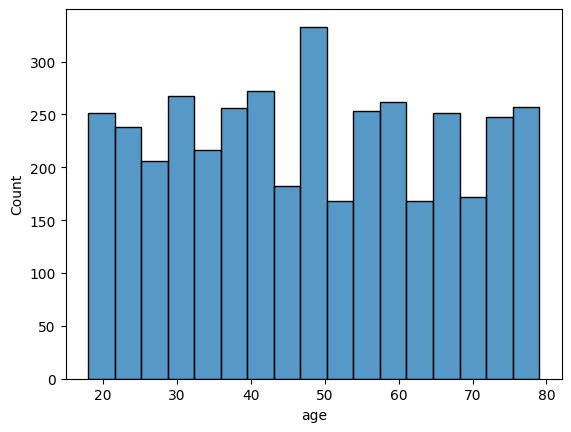

In [31]:
# Histograma para visualizar la edad (age)

sns.histplot(user_profile['age'])
plt.show()


💡Insights: 
Al analizar el histograma de edad (age), se observa:

1. Distribución Uniforme y Perfil del Usuario
A diferencia de otros servicios que suelen concentrarse en jóvenes, los usuarios de ConnectaTel están distribuidos de forma casi uniforme entre los 20 y los 80 años.

Insight: No tienes un "público objetivo" único por edad; la empresa tiene éxito captando clientes de todas las generaciones.

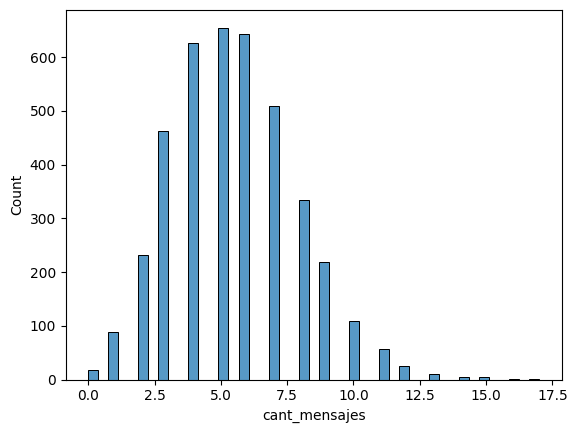

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'])
plt.show()


1. Comportamiento del Consumidor (Sesgo a la derecha)
A diferencia del gráfico de edades que era uniforme, este tiene un sesgo a la derecha (asimetría positiva).

**Insight:** La gran mayoría de tus usuarios son consumidores "ligeros" o moderados de SMS. El volumen más alto de personas envía entre 4 y 6 mensajes.

2. Identificación del "Usuario Típico"
El pico máximo (la moda) está en los 5 mensajes.

Hay una caída muy rápida después de los 8 mensajes. Esto sugiere que el servicio de mensajes de ConnectaTel se usa para comunicaciones breves y puntuales, no como una herramienta de chat intensivo.

3. Detección de "Power Users" (Outliers)
Tenemos una "cola" larga que llega hasta los 15-17 mensajes. Aunque son pocos usuarios, estos son clientes de alto valor en el segmento de texto.

Estrategia: Podemos proponer un análisis cruzado para ver si estos usuarios que envían +10 mensajes están en el plan Básico; si es así, son candidatos perfectos para una campaña de upgrade al plan Premium.

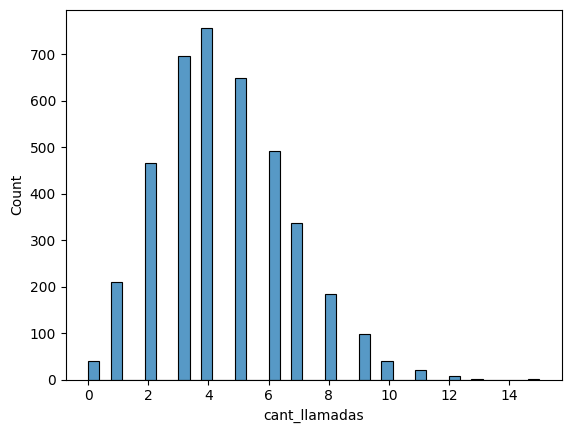

In [33]:
# Histograma para visualizar la cant_llamadas

sns.histplot(user_profile['cant_llamadas'])
plt.show()


💡Insights: 
1. Perfil de Uso de Voz
Al igual que con los mensajes, tenemos una distribución asimétrica positiva. La mayoría de los usuarios no realiza una cantidad masiva de llamadas.

El pico de actividad (la moda) se encuentra entre las 3 y 4 llamadas. Es el comportamiento estándar del cliente de ConnectaTel.

2. Comparativa Voz vs. Mensajes
Si comparamos este gráfico con el anterior de cant_mensajes:

Frecuencia: El pico de llamadas (3-4) es ligeramente menor al de mensajes (5). Esto sugiere que el usuario promedio prefiere textear antes que llamar, una tendencia común en el mercado actual de telecomunicaciones.

Usuarios "Inactivos": Hay una barra muy pequeña en el 0. Esto es positivo; indica que casi todos los usuarios en de esta muestra están utilizando activamente el servicio de voz.

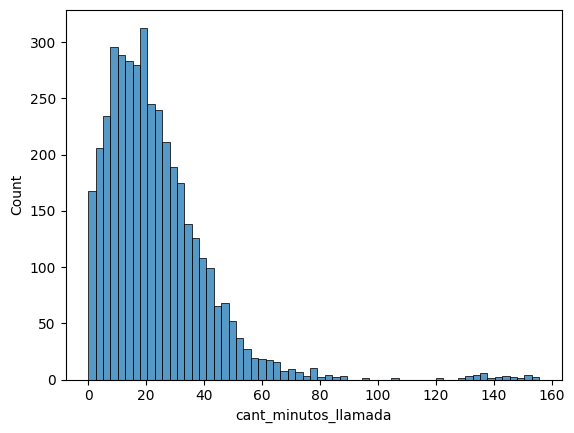

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'])
plt.show()


💡Insights: 
1. El "Corazón" del Consumo (Moda y Media)
La distribución es asimétrica positiva, con la mayor concentración de usuarios hablando entre 10 y 25 minutos.

El pico máximo (la barra más alta) se encuentra cerca de los 18-20 minutos. Esto sugiere que las llamadas de ConnectaTel tienden a ser de duración media-larga, lo cual es un indicador de que el servicio se usa para conversaciones sustanciales, no solo para avisos rápidos.

2. Segmentación de Usuarios por "Engagement"
Usuarios Breves (0-5 min): Hay un grupo inicial considerable. Estos podrían ser usuarios que usan el teléfono para coordinaciones rápidas.

Usuarios Estándar (10-40 min): Es tu masa crítica de clientes.

Usuarios Intensivos (45-80 min): Aquí la frecuencia baja, pero son usuarios que generan mucha carga en la red.

3. Anomalía Detectada: Los "Super Habladores" (Outliers extremos)
Nota que entre los 130 y 160 minutos, aparecen pequeñas barras aisladas.

Insight Técnico: Estos son valores atípicos (outliers). Tener personas hablando más de dos horas seguidas podría indicar dos cosas: o clientes con necesidades muy específicas (negocios, soporte), o posibles errores de medición (llamadas que no se "colgaron" correctamente en el sistema).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

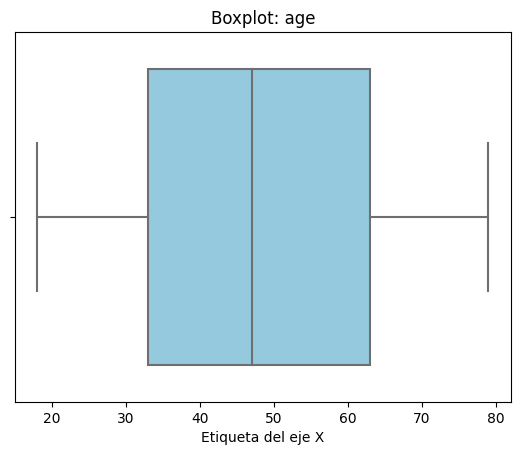

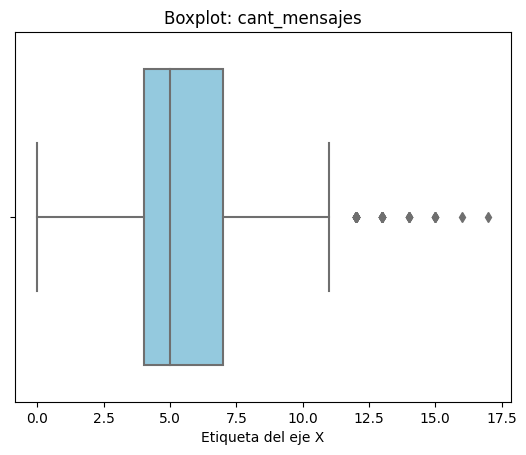

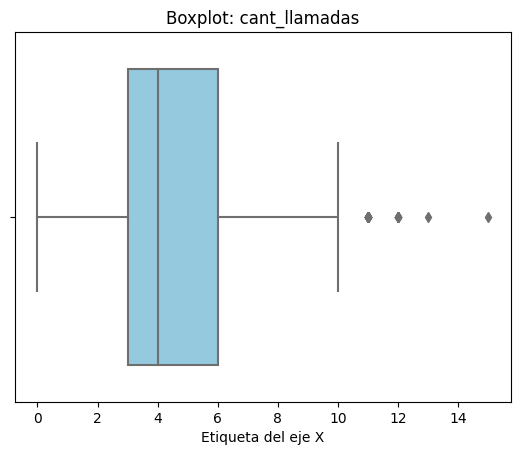

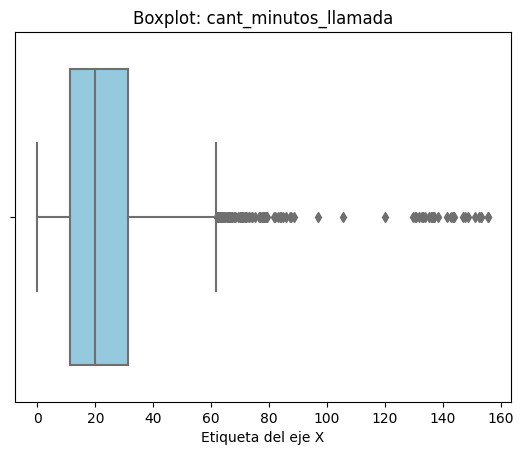

In [35]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for box in columnas_numericas:
    sns.boxplot(x=user_profile[box], color='skyblue')
    plt.title(f'Boxplot: {box}')
    plt.xlabel('Etiqueta del eje X')
    plt.show()



In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Crear un diccionario para almacenar los límites
limites_iqr = {}

for col in columnas_limites:
    # Calcular Q1 (percentil 25) y Q3 (percentil 75)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    # Calcular el IQR
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Guardar en el diccionario
    limites_iqr[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    # Mostrar resultados
    print(f"\n=== {col.upper()} ===")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")



=== CANT_MENSAJES ===
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50

=== CANT_LLAMADAS ===
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50

=== CANT_MINUTOS_LLAMADA ===
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_minutos_llamada: mantener o no outliers, porqué?

1. cant_mensajes y cant_llamadas (Mantener)
Análisis: El máximo de mensajes es 17 y el de llamadas es 15. Si miras la desviación estándar (std) de ~2, estos valores están a unas 4 o 5 desviaciones estándar de la media.

Decisión: Mantenlos.

Razón: En telecomunicaciones, es perfectamente normal que un usuario envíe 17 mensajes o haga 15 llamadas en un periodo. No son errores de sistema, son comportamientos reales de "Power Users". Eliminarlos sesgaría tu análisis de ingresos, ya que estos son tus clientes más activos.

2. cant_minutos_llamada (Analizar/Filtrar)
Análisis: Aquí el salto es drástico. El 75% de la gente habla hasta 31 minutos, ¡pero el máximo es de 155 minutos! Estamos hablando de un valor que es 5 veces más grande que el tercer cuartil.

Decisión: Mantener con observación o aplicar un tope.

Razón: Una llamada de 2.5 horas es posible, pero poco común.

**Acción Técnica:**
En lugar de borrarlos, Debemos crear una columna de "Segmento de Uso": Normal: <= 61 min. Intensivo (Outlier): > 61 min. 
Esto permitirá analizar la rentabilidad de los "Intensivos" por separado en tu portafolio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso

#Funsión para clasificar uso
def classify_use(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    # Verificar si hay valores nulos
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error de datos"
    # Comparacion para evaluar las condisiones de llamadas y mensajes
    
    if  llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la funsión

user_profile['grupo_uso'] = user_profile.apply(classify_use, axis=1)
        


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad

#Funsión para clasificar uso
def classify_age(row):
    edad = row['age']
   
    # Verificar si hay valores nulos
    if pd.isna(edad):
        return "Error de datos"
        
    # Comparacion para evaluar las edades
    if  edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto mayor'

# Aplicar la funsión

user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)
        


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

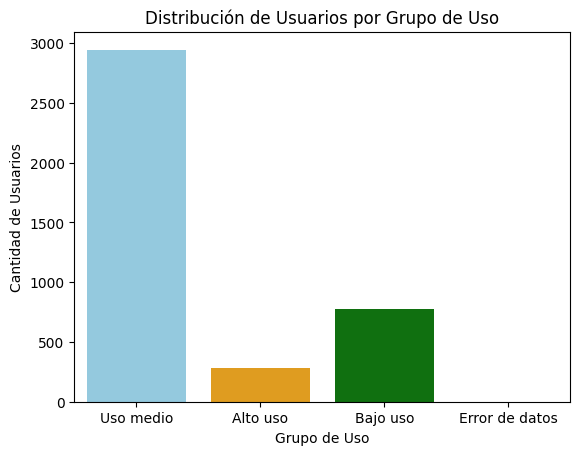

In [44]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'orange', 'green'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

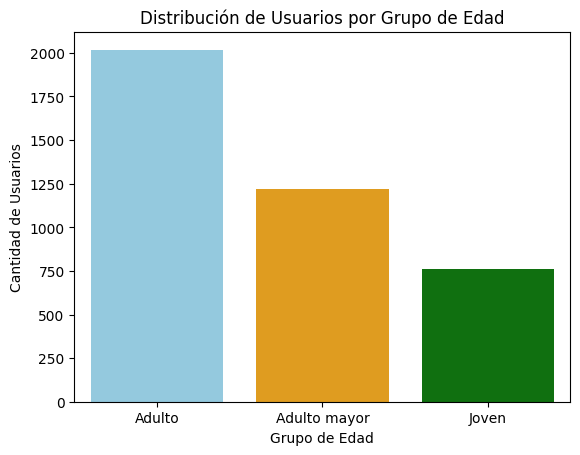

In [45]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'orange', 'green'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
El dataset presentaba tres fallas críticas de integridad que comprometían la calidad del análisis:
•	Valores Centinela en Edad: Se detectaron valores de -999, lo cual es físicamente imposible y sesgaba la media de edad hacia abajo.
•	Fechas Inconsistentes ("Datos del futuro"): Había 40 registros (1%) con fechas de registro en 2026, a pesar de que los datos operativos de ConnectaTel solo llegaban hasta 2024.
•	Valores Nulos Estandarizados: Se identificaron nulos "disfrazados" con el carácter '?' en la columna de ciudades (96 registros) y valores faltantes en churn_date (88%), aunque estos últimos se validaron como informativos (clientes activos).
•	Inconsistencias de Tipo: En el dataframe de consumos, el 55% de los datos de duración eran nulos, lo que se identificó como una segregación lógica entre mensajes y llamadas, no como pérdida de información.



Mediante ingeniería de variables, logre segmentar la base de la siguiente manera:
🔍 **Segmentos por Edad**
    o	Adultos (Líderes): El segmento más grande (+2,000 usuarios). Es la base del negocio.
    o	Adultos Mayores: Un grupo significativo que muestra lealtad y uso constante de voz.
    o	Jóvenes: El segmento más pequeño, sugiriendo un área de oportunidad para captación.
📊 **Segmentos por Nivel de Uso**
    o	Uso Medio (75%): El cliente estándar que garantiza la rentabilidad predecible.
    o	Bajo Uso: Usuarios que probablemente están subutilizando su plan.
    o	Alto Uso (<12%): El nicho que consume el máximo de recursos de red (voz y texto).

➡️ Esto sugiere que ...
•	El segmento "Adulto" de "Uso Medio": Es el más valioso por volumen y estabilidad. Generan ingresos constantes sin representar un riesgo de saturación para la infraestructura.
•	Los "Power Users" (Alto Uso): Son valiosos si están en el plan Premium. Si están en el Básico, son los mejores candidatos para una estrategia de upselling (migración de plan) para aumentar el ticket promedio.
•	En Voz: Se detectó una "lluvia de outliers" en la duración de llamadas, con casos que superan los 150 minutos, cuando el límite normal (IQR) es de 61.8 minutos.
•	En Mensajería: Usuarios que envían hasta 17 SMS, triplicando la mediana de consumo (5).
•	Implicación para el negocio: Estos outliers no son errores, son comportamientos reales. Implican una carga desigual en la red y la necesidad de monitorear la rentabilidad de los planes ilimitados para asegurar que estos usuarios no generen pérdidas operativas.

💡 **Recomendaciones**

Basado en los patrones detectados, mis recomendaciones técnicas son:
1.	Plan "Segunda Juventud": Dado el gran volumen de Adultos Mayores, un plan con minutos ilimitados y pocos datos/mensajes sería altamente atractivo, ya que valoran más la voz.
2.	Ajuste de Topes en Plan Básico: Establecer un límite de 60 minutos por llamada en el plan Básico para incentivar el salto al plan Premium de aquellos usuarios detectados como outliers.
3.	Campaña de Retención para Jóvenes: Crear un plan con mayor enfoque en datos o mensajes (Alto Uso de texto) para aumentar la participación en este segmento de edad que actualmente es el más bajo.
4.	Monetización de Power Users: Ofrecer "Add-ons" (paquetes adicionales) específicos de minutos para usuarios de 'Bajo Uso' que ocasionalmente necesitan hacer llamadas largas, sin obligarlos a cambiar de plan.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`